# Завдання 1:
Обрати унікальний датасет

обрано [Heart Disease](https://archive.ics.uci.edu/dataset/45/heart+disease)


In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import urllib.request

sns.set_theme(style="whitegrid", palette="muted")

dataset_link = "https://archive.ics.uci.edu/ml/machine-learning-databases/heart-disease/processed.cleveland.data"
local_file = Path("cleveland_heart_data.csv")

columns = [
    "age", "sex", "cp", "trestbps", "chol", "fbs", "restecg", 
    "thalach", "exang", "oldpeak", "slope", "ca", "thal", "target"
]

if not local_file.is_file():
    print("Локального файлу не знайдено. Завантаження з UCI...")
    opener = urllib.request.build_opener()
    opener.addheaders = [('User-agent', 'Mozilla/5.0')]
    urllib.request.install_opener(opener)
    urllib.request.urlretrieve(dataset_link, local_file)
    print("Завантаження завершено.")
else:
    print("Файл знайдено локально.")

heart_df = pd.read_csv(local_file, names=columns)

print(f"Розмірність датасету: {heart_df.shape}")
display(heart_df.head())

Локального файлу не знайдено. Завантаження з UCI...
Завантаження завершено.
Розмірність датасету: (303, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,63.0,1.0,1.0,145.0,233.0,1.0,2.0,150.0,0.0,2.3,3.0,0.0,6.0,0
1,67.0,1.0,4.0,160.0,286.0,0.0,2.0,108.0,1.0,1.5,2.0,3.0,3.0,2
2,67.0,1.0,4.0,120.0,229.0,0.0,2.0,129.0,1.0,2.6,2.0,2.0,7.0,1
3,37.0,1.0,3.0,130.0,250.0,0.0,0.0,187.0,0.0,3.5,3.0,0.0,3.0,0
4,41.0,0.0,2.0,130.0,204.0,0.0,2.0,172.0,0.0,1.4,1.0,0.0,3.0,0


# Завдання 2:
Здійснити Data Cleaning

In [16]:
# Знаходимо рядки, які містять знаки питання або NaN
invalid_rows = heart_df[heart_df.isin(['?', np.nan]).any(axis=1)]

print(f"Знайдено проблемних рядків: {len(invalid_rows)}")
if len(invalid_rows) > 0:
    print("Ось конкретні дані, які будуть видалені:")
    display(invalid_rows)

# Саме очищення
heart_df = heart_df.replace('?', np.nan).dropna()
heart_df = heart_df.apply(pd.to_numeric)
heart_df = heart_df.drop_duplicates()

print(f"\nОчищення завершено. Фінальна кількість рядків: {len(heart_df)}")

Знайдено проблемних рядків: 6
Ось конкретні дані, які будуть видалені:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
87,53.0,0.0,3.0,128.0,216.0,0.0,2.0,115.0,0.0,0.0,1.0,0.0,?,0
166,52.0,1.0,3.0,138.0,223.0,0.0,0.0,169.0,0.0,0.0,1.0,?,3.0,0
192,43.0,1.0,4.0,132.0,247.0,1.0,2.0,143.0,1.0,0.1,2.0,?,7.0,1
266,52.0,1.0,4.0,128.0,204.0,1.0,0.0,156.0,1.0,1.0,2.0,0.0,?,2
287,58.0,1.0,2.0,125.0,220.0,0.0,0.0,144.0,0.0,0.4,2.0,?,7.0,0
302,38.0,1.0,3.0,138.0,175.0,0.0,0.0,173.0,0.0,0.0,1.0,?,3.0,0



Очищення завершено. Фінальна кількість рядків: 297


# Завдання 3: Побудувати графіки залежності одного integer/real атрибута від іншого (lineplot, scatter etc).


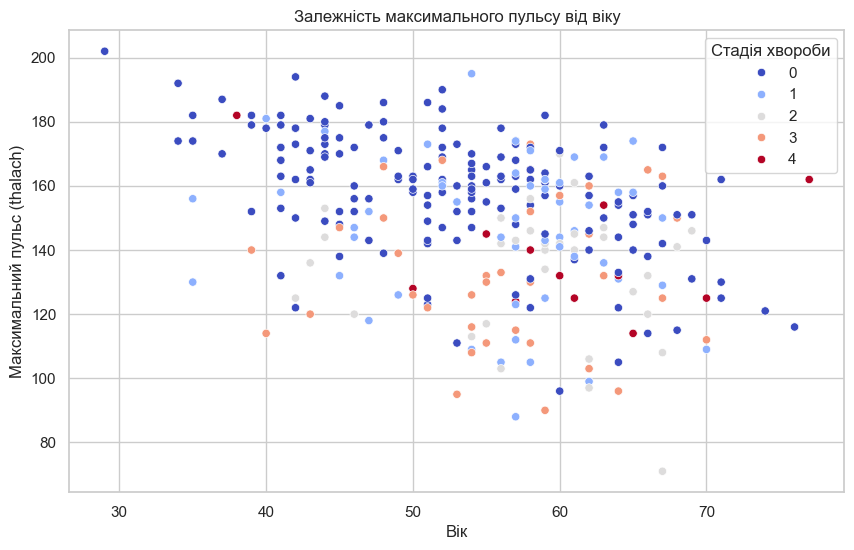

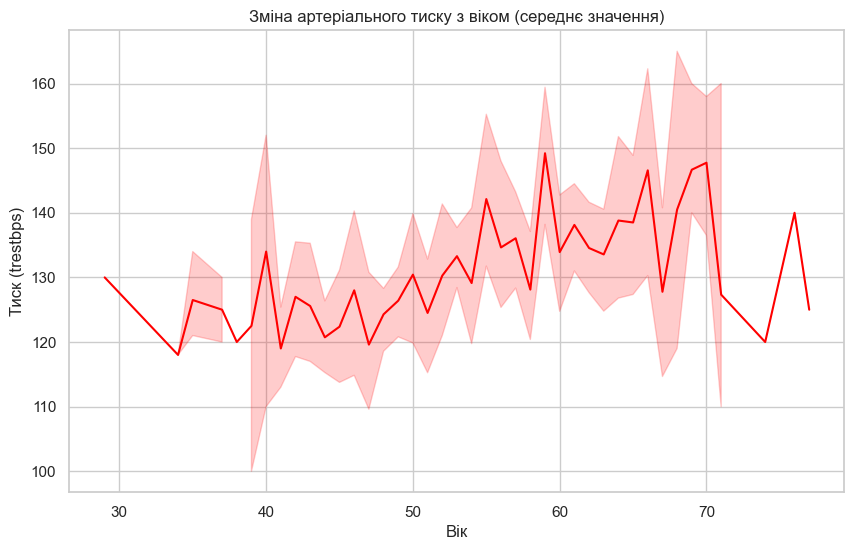

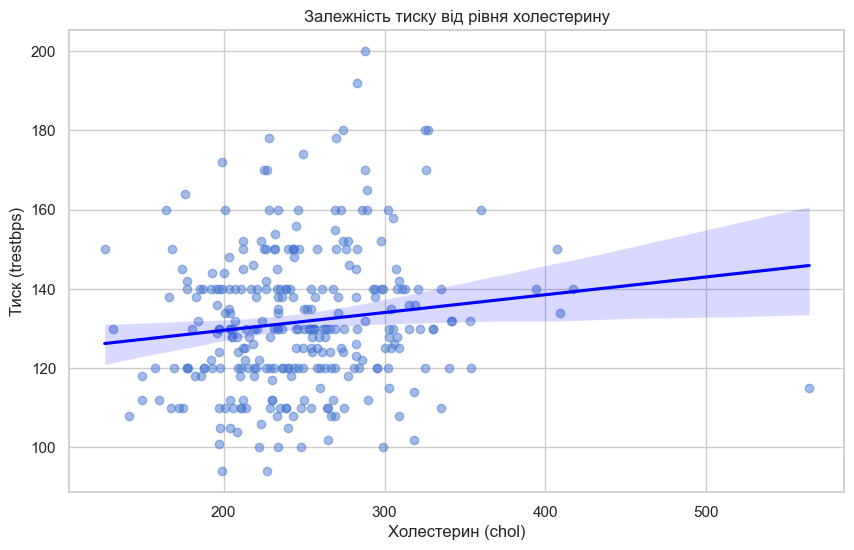

In [17]:
# 1. Scatter plot: Залежність максимального пульсу (thalach) від віку (age)
plt.figure(figsize=(10, 6))
sns.scatterplot(x='age', y='thalach', data=heart_df, hue='target', palette='coolwarm')
plt.title('Залежність максимального пульсу від віку')
plt.xlabel('Вік')
plt.ylabel('Максимальний пульс (thalach)')
plt.legend(title='Стадія хвороби')
plt.show()

# 2. Line plot: Середня залежність артеріального тиску (trestbps) від віку
plt.figure(figsize=(10, 6))
sns.lineplot(x='age', y='trestbps', data=heart_df, color='red')
plt.title('Зміна артеріального тиску з віком (середнє значення)')
plt.xlabel('Вік')
plt.ylabel('Тиск (trestbps)')
plt.show()

# 3. Regression plot: Зв'язок холестерину та тиску
plt.figure(figsize=(10, 6))
sns.regplot(x='chol', y='trestbps', data=heart_df, scatter_kws={'alpha':0.5}, line_kws={'color':'blue'})
plt.title('Залежність тиску від рівня холестерину')
plt.xlabel('Холестерин (chol)')
plt.ylabel('Тиск (trestbps)')
plt.show()

# Завдання 4: Побудувати гістограму по одному з атрибутів, що буде показувати на кількість елементів, що знаходяться у 5 діапазонах, які ви задасте.


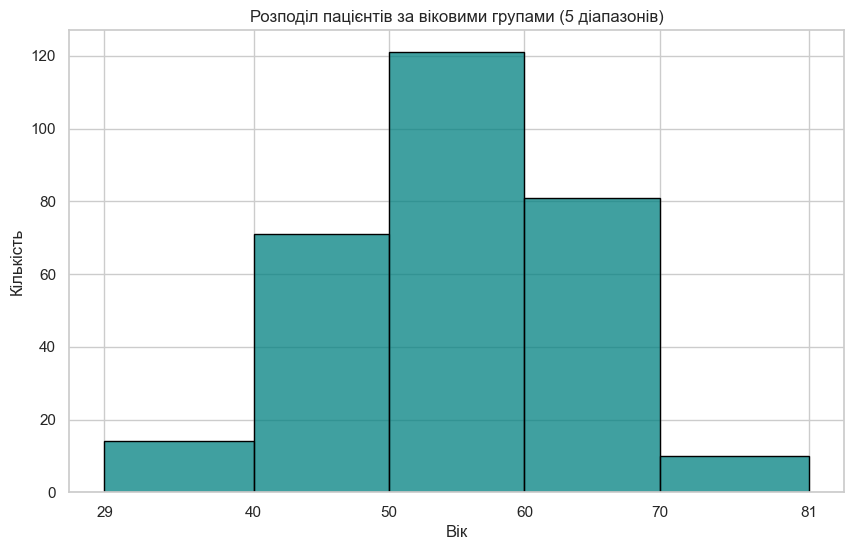

In [18]:
plt.figure(figsize=(10, 6))
bins = [29, 40, 50, 60, 70, 81]
sns.histplot(heart_df['age'], bins=bins, color='teal', edgecolor='black')
plt.title('Розподіл пацієнтів за віковими групами (5 діапазонів)')
plt.xlabel('Вік')
plt.ylabel('Кількість')
plt.xticks(bins)
plt.show()

# Завдання 5: Збудувати графіки, використовуючи приклади, наведені у https://medium.com/data-science/the-art-of-effective-visualization-of-multi-dimensional-data-6c7202990c57 


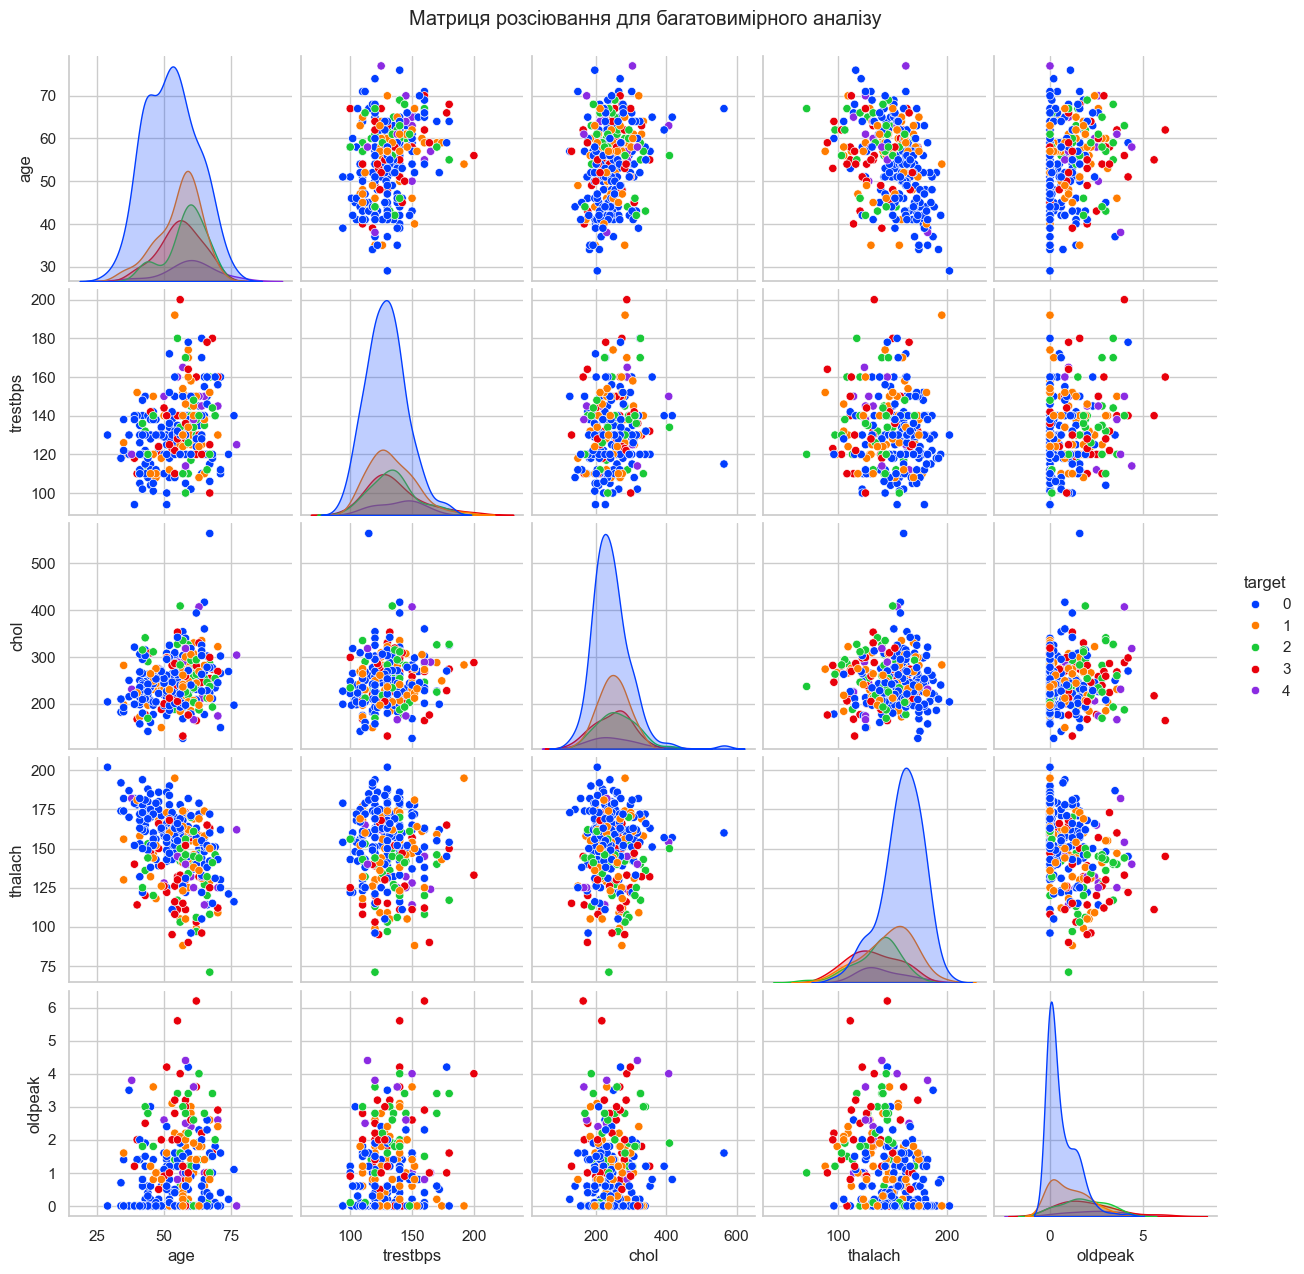

In [20]:
features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

# Будуємо матрицю розсіювання з розділенням за цільовою змінною
sns.pairplot(heart_df[features + ['target']], hue='target', palette='bright', diag_kind='kde')
plt.suptitle('Матриця розсіювання для багатовимірного аналізу', y=1.02)
plt.show()


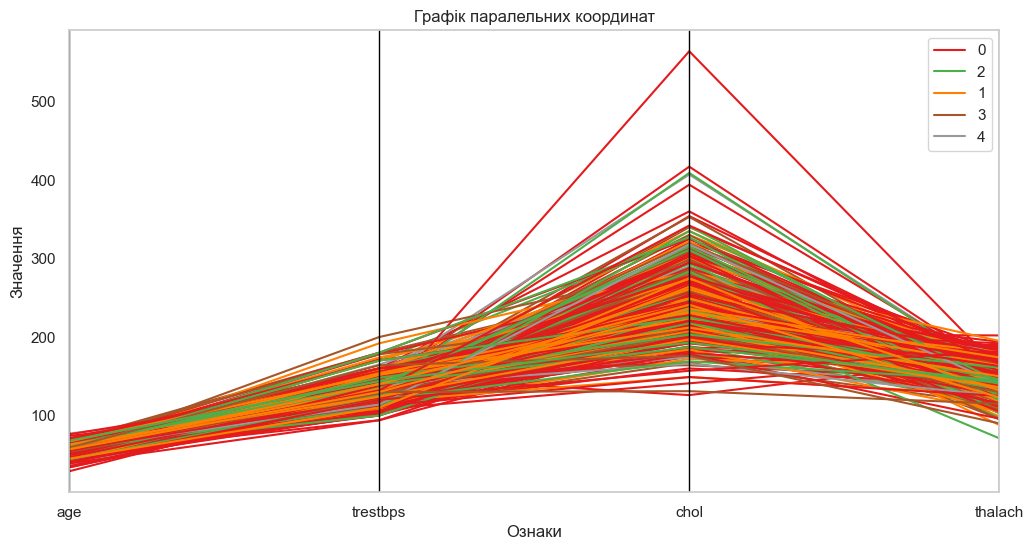

In [21]:
from pandas.plotting import parallel_coordinates

# Обираємо кілька ознак та нормалізуємо їх для наочності (опціонально)
cols_to_show = ['age', 'trestbps', 'chol', 'thalach', 'target']
df_norm = heart_df[cols_to_show].copy()

plt.figure(figsize=(12, 6))
parallel_coordinates(df_norm, 'target', colormap=plt.get_cmap("Set1"))
plt.title('Графік паралельних координат')
plt.xlabel('Ознаки')
plt.ylabel('Значення')
plt.show()

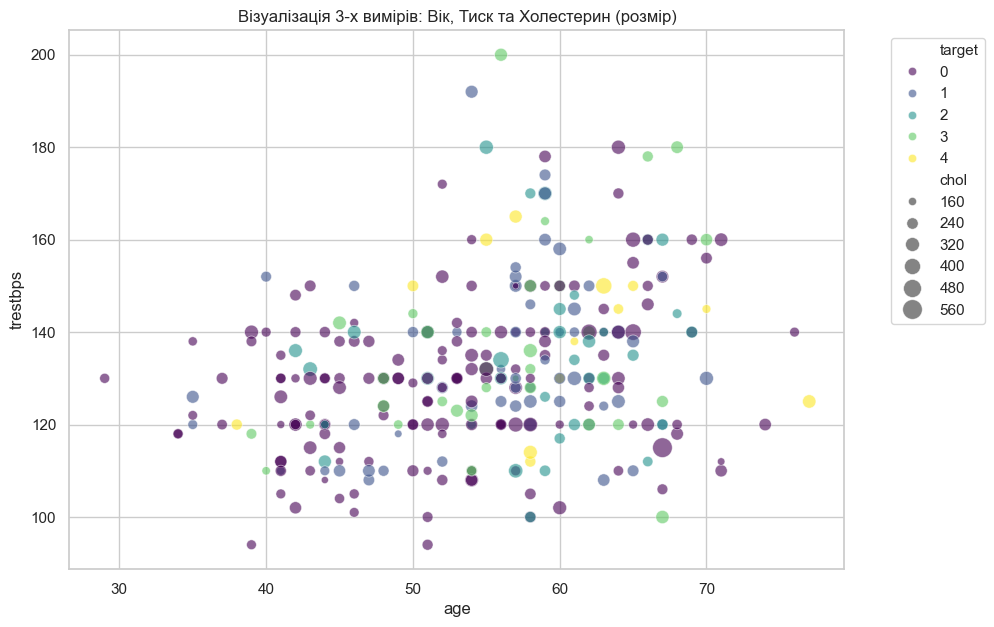

In [22]:
plt.figure(figsize=(10, 7))
# X=вік, Y=тиск, Розмір=холестерин, Колір=результат
sns.scatterplot(x='age', y='trestbps', size='chol', hue='target', 
                sizes=(20, 200), alpha=0.6, palette='viridis', data=heart_df)

plt.title('Візуалізація 3-х вимірів: Вік, Тиск та Холестерин (розмір)')
plt.legend(bbox_to_anchor=(1.05, 1), loc=2)
plt.show()

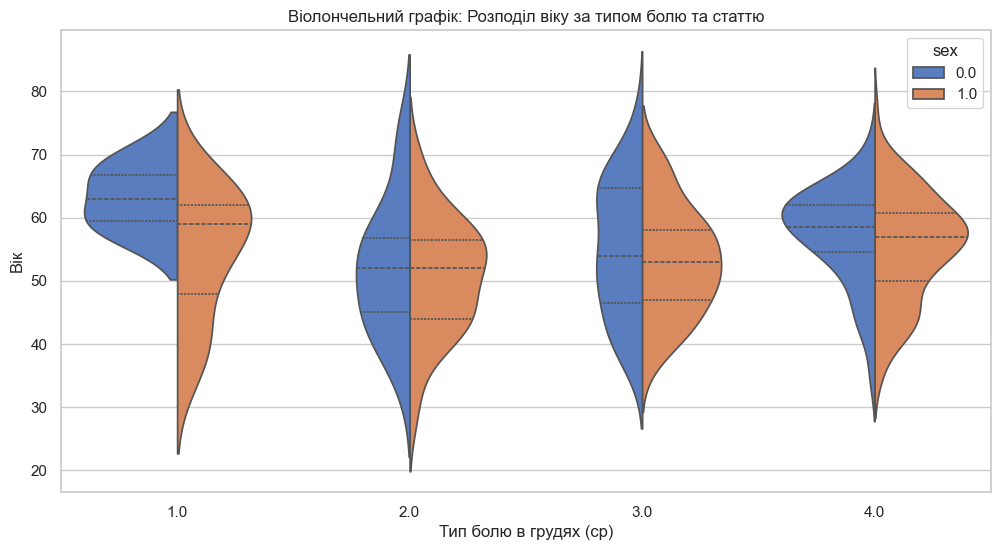

In [23]:
plt.figure(figsize=(12, 6))
# x=тип болю в грудях (cp), y=вік, hue=стать
sns.violinplot(x='cp', y='age', hue='sex', data=heart_df, split=True, inner="quart", palette='muted')
plt.title('Віолончельний графік: Розподіл віку за типом болю та статтю')
plt.xlabel('Тип болю в грудях (cp)')
plt.ylabel('Вік')
plt.show()

# Завдання 6: Побудувати інші графіки, що покажуть корисну інформацію про датасет. Загальна кількість графіків має становити 5-8.


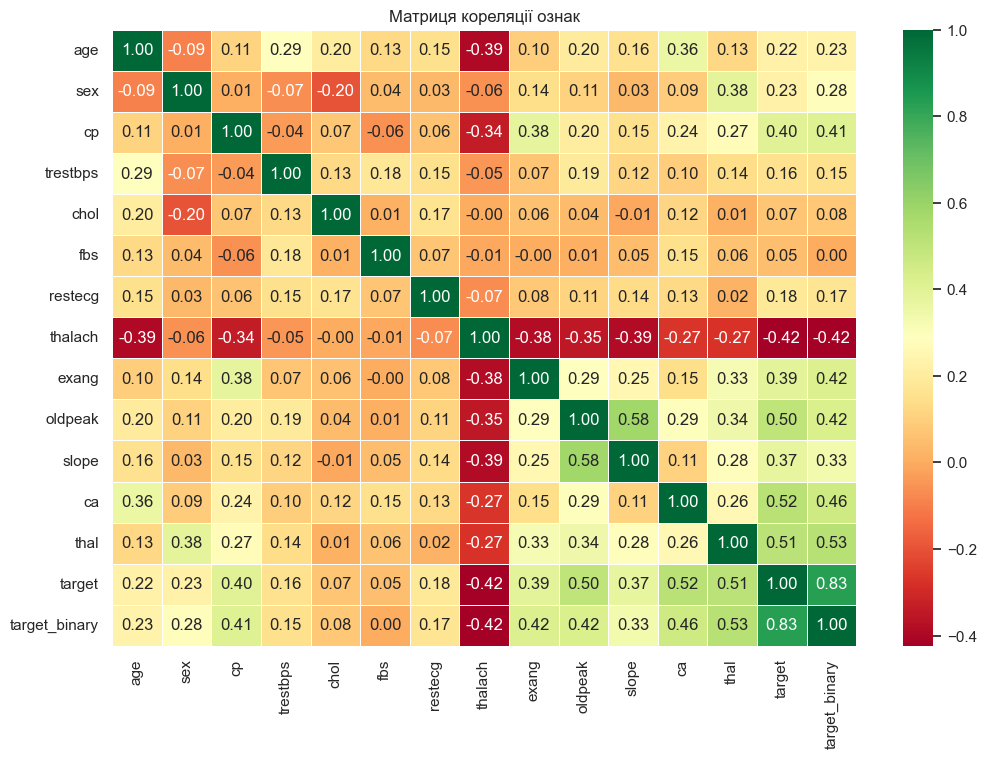

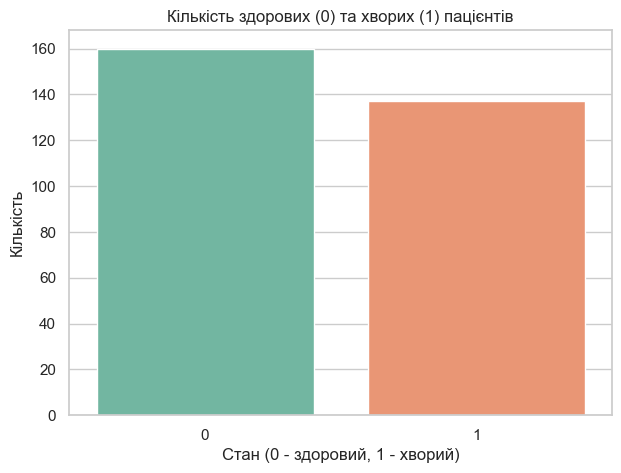

In [27]:
# 1. Теплокарта кореляцій
plt.figure(figsize=(12, 8))
sns.heatmap(heart_df.corr(), annot=True, cmap='RdYlGn', fmt='.2f', linewidths=0.5)
plt.title('Матриця кореляції ознак')
plt.show()

# 2. Розподіл цільової змінної (хворі vs здорові)
plt.figure(figsize=(7, 5))
heart_df['target_binary'] = (heart_df['target'] > 0).astype(int)

sns.countplot(x='target_binary', data=heart_df, hue='target_binary', palette='Set2', legend=False)

plt.title('Кількість здорових (0) та хворих (1) пацієнтів')
plt.xlabel('Стан (0 - здоровий, 1 - хворий)')
plt.ylabel('Кількість')
plt.show()

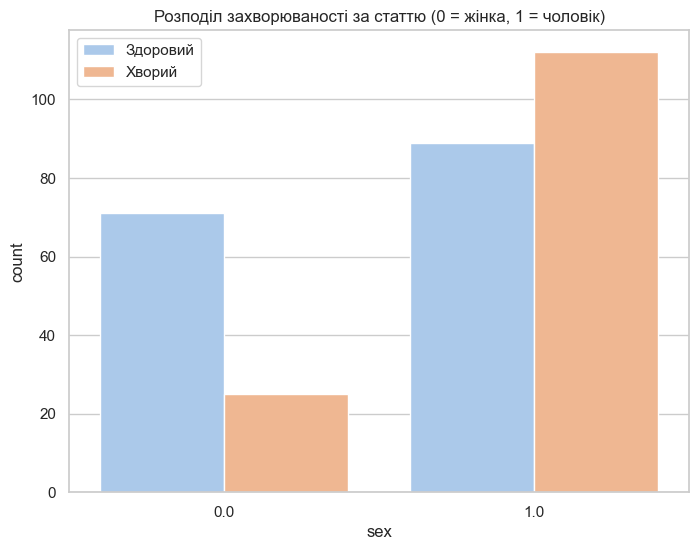

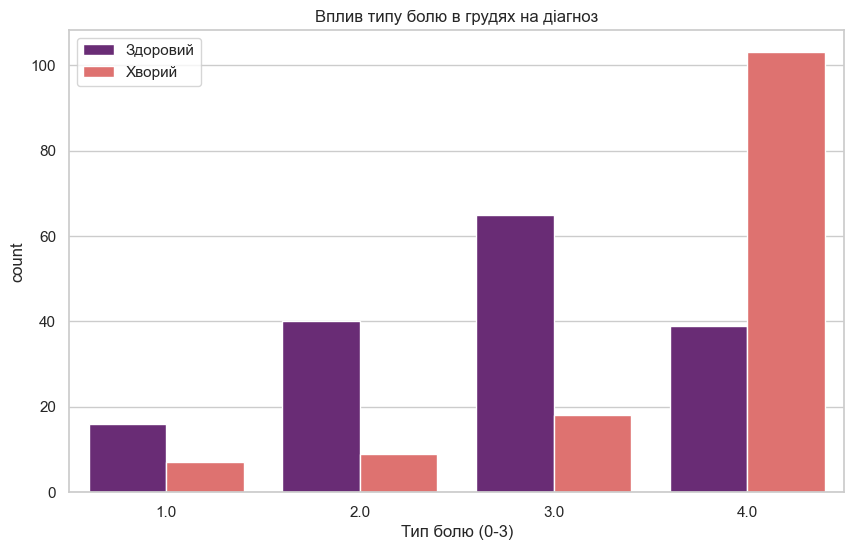

In [25]:
# 3. Залежність хвороби від статі
plt.figure(figsize=(8, 6))
sns.countplot(x='sex', hue='target_binary', data=heart_df, palette='pastel')
plt.title('Розподіл захворюваності за статтю (0 = жінка, 1 = чоловік)')
plt.legend(['Здоровий', 'Хворий'])
plt.show()

# 4. Тип болю в грудях (cp) та стан пацієнта
plt.figure(figsize=(10, 6))
sns.countplot(x='cp', hue='target_binary', data=heart_df, palette='magma')
plt.title('Вплив типу болю в грудях на діагноз')
plt.xlabel('Тип болю (0-3)')
plt.legend(['Здоровий', 'Хворий'])
plt.show()

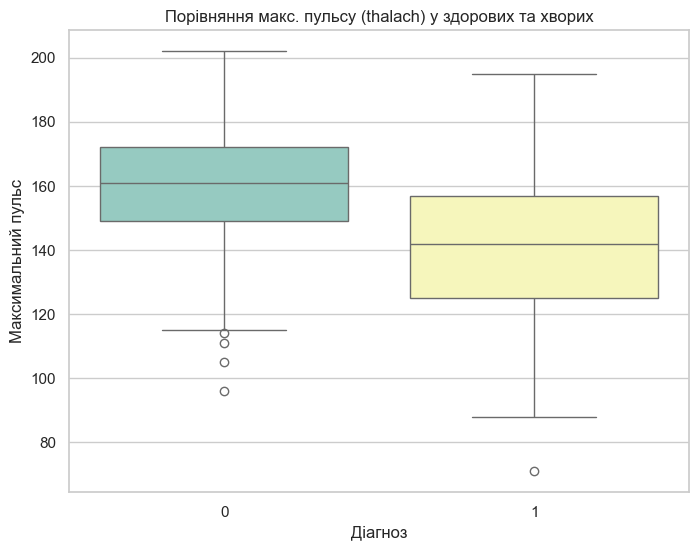

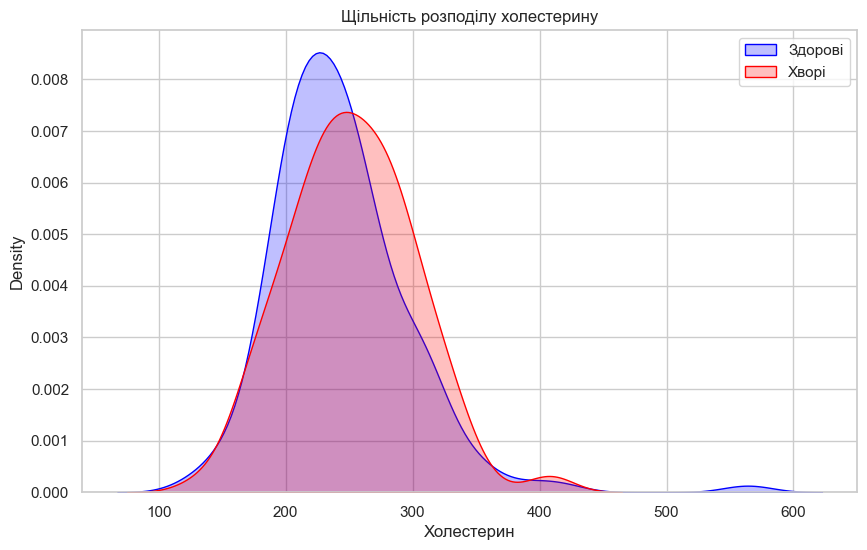

In [28]:
# 5. Boxplot: Максимальний пульс залежно від діагнозу
plt.figure(figsize=(8, 6))
# Виправлено: додано hue та legend=False
sns.boxplot(x='target_binary', y='thalach', data=heart_df, hue='target_binary', palette='Set3', legend=False)
plt.title('Порівняння макс. пульсу (thalach) у здорових та хворих')
plt.xlabel('Діагноз')
plt.ylabel('Максимальний пульс')
plt.show()

# 6. KDE Plot: Розподіл холестерину
plt.figure(figsize=(10, 6))
# Виправлено: параметр shade замінено на fill (вимога нових версій seaborn)
sns.kdeplot(heart_df[heart_df['target_binary'] == 0]['chol'], fill=True, color="blue", label="Здорові")
sns.kdeplot(heart_df[heart_df['target_binary'] == 1]['chol'], fill=True, color="red", label="Хворі")
plt.title('Щільність розподілу холестерину')
plt.xlabel('Холестерин')
plt.legend()
plt.show()